# The Pirate's Growth Strategy: Scaling a Digital Ecosystem through Unit Economics

## Track 2 v4 - Pirate Growth Audit
**Dataset:** UCI Online Retail II (1,067,371 raw transactions, Dec 2009 - Dec 2011)

**Scenario (honest reframe):** A mid-market e-commerce platform (subscription-like repeat-purchase model)
is struggling with high CAC. The board wants a recommendation on **Dynamic Pricing vs Referral Loop**
to improve LTV/CAC.

**Hero method:** AARRR (Pirate Metrics) funnel + Cohort retention + Market Basket lift
+ Nash Equilibrium on penetration pricing + Decision Tree EV.

**Tasks:**
1. AARRR Pirate Metrics funnel
2. Cohort retention + Market Basket Analysis
3. Game Theory (Nash) + STP segmentation
4. Decision Tree EV (Dynamic Pricing vs Referral Loop)

**Deliverable:** Power BI Growth Command Center spec (DAX) + MECE 6-month roadmap.


In [1]:
# === Path setup ===
from pathlib import Path
import os, sys

CWD = Path.cwd().resolve()
candidates = [CWD] + list(CWD.parents)
PROJECT_ROOT = None
for p in candidates:
    if (p / 'data').exists() and any((p / 'data').glob('online_retail*')):
        PROJECT_ROOT = p
        break
    if p.name in ('pirate_growth', 'PirateGrowth_Track2v4_Bundle'):
        PROJECT_ROOT = p
        break
if PROJECT_ROOT is None:
    PROJECT_ROOT = CWD

DATA_DIR = PROJECT_ROOT / 'data'
OUT_DIR = PROJECT_ROOT / 'outputs'
FIG_DIR = PROJECT_ROOT / 'figures'
for d in (OUT_DIR, FIG_DIR):
    d.mkdir(exist_ok=True, parents=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from itertools import combinations

plt.rcParams['figure.dpi'] = 100
np.random.seed(42)

DATA_FILE = next(DATA_DIR.glob('online_retail*'))
print(f"Loading {DATA_FILE.name} ...")

y1 = pd.read_excel(DATA_FILE, sheet_name='Year 2009-2010')
y2 = pd.read_excel(DATA_FILE, sheet_name='Year 2010-2011')
df = pd.concat([y1, y2], ignore_index=True)
df.columns = [c.replace(' ', '_') for c in df.columns]
print(f"Combined raw rows: {len(df):,}")

clean = df[(df['Customer_ID'].notna()) & (df['Quantity']>0) & (df['Price']>0)].copy()
clean['Customer_ID'] = clean['Customer_ID'].astype(int)
clean['StockCode'] = clean['StockCode'].astype(str)
clean['Revenue'] = clean['Quantity'] * clean['Price']
clean['order_month'] = clean['InvoiceDate'].dt.to_period('M')

print(f"Clean rows: {len(clean):,} ({len(clean)/len(df)*100:.1f}%)")
print(f"Customers: {clean['Customer_ID'].nunique():,} | Products: {clean['StockCode'].nunique():,}")
print(f"Total revenue: GBP {clean['Revenue'].sum():,.0f}")


PROJECT_ROOT: /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 06/Track 02/PirateGrowth_Track2v4_Bundle
Loading online_retail_II.xlsx ...
Combined raw rows: 1,067,371
Clean rows: 805,549 (75.5%)
Customers: 5,878 | Products: 4,631
Total revenue: GBP 17,743,429


---
## Task 1 - AARRR Pirate Metrics Funnel

The five stages: **Acquisition, Activation, Retention, Referral, Revenue.** Goal: identify the biggest drop-off.


In [2]:
# Acquisition: signups by cohort month
first_order = clean.groupby('Customer_ID')['order_month'].min().reset_index()
first_order.columns = ['Customer_ID', 'cohort_month']
cohort_sizes = first_order['cohort_month'].value_counts().sort_index()

print("ACQUISITION - Top cohorts:")
print(cohort_sizes.head(12))
print(f"\nTotal signups across {len(cohort_sizes)} cohorts: {len(first_order):,}")
print(f"Largest cohort: {cohort_sizes.idxmax()} ({cohort_sizes.max()} customers)")

# Activation: 2nd purchase within 30 days
clean_sorted = clean.sort_values(['Customer_ID', 'InvoiceDate'])
cust_invoices = clean_sorted.groupby(['Customer_ID', 'Invoice'])['InvoiceDate'].min().reset_index()
cust_invoices = cust_invoices.sort_values(['Customer_ID', 'InvoiceDate'])
cust_invoices['order_rank'] = cust_invoices.groupby('Customer_ID').cumcount() + 1

first_inv = cust_invoices[cust_invoices['order_rank']==1][['Customer_ID','InvoiceDate']].rename(columns={'InvoiceDate':'first_inv'})
second_inv = cust_invoices[cust_invoices['order_rank']==2][['Customer_ID','InvoiceDate']].rename(columns={'InvoiceDate':'second_inv'})
fs = first_inv.merge(second_inv, on='Customer_ID', how='left')
fs['days_to_2nd'] = (fs['second_inv'] - fs['first_inv']).dt.days

n_total = len(fs)
n_act_30 = (fs['days_to_2nd']<=30).sum()
n_act_90 = (fs['days_to_2nd']<=90).sum()
n_no_2nd = fs['second_inv'].isna().sum()

print(f"\n=== ACTIVATION ===")
print(f"Activated <=30d:  {n_act_30:,} ({100*n_act_30/n_total:.1f}%)")
print(f"Activated <=90d:  {n_act_90:,} ({100*n_act_90/n_total:.1f}%)")
print(f"Never 2nd purchase: {n_no_2nd:,} ({100*n_no_2nd/n_total:.1f}%)")
print(f"\n>>> BIGGEST DROP-OFF: Activation. {100-100*n_act_30/n_total:.1f}% fail to make 2nd purchase within 30d.")


ACQUISITION - Top cohorts:
cohort_month
2009-12    955
2010-01    383
2010-02    374
2010-03    443
2010-04    294
2010-05    254
2010-06    270
2010-07    186
2010-08    162
2010-09    243
2010-10    377
2010-11    325
Freq: M, Name: count, dtype: int64

Total signups across 25 cohorts: 5,878
Largest cohort: 2009-12 (955 customers)

=== ACTIVATION ===
Activated <=30d:  1,388 (23.6%)
Activated <=90d:  2,745 (46.7%)
Never 2nd purchase: 1,623 (27.6%)

>>> BIGGEST DROP-OFF: Activation. 76.4% fail to make 2nd purchase within 30d.


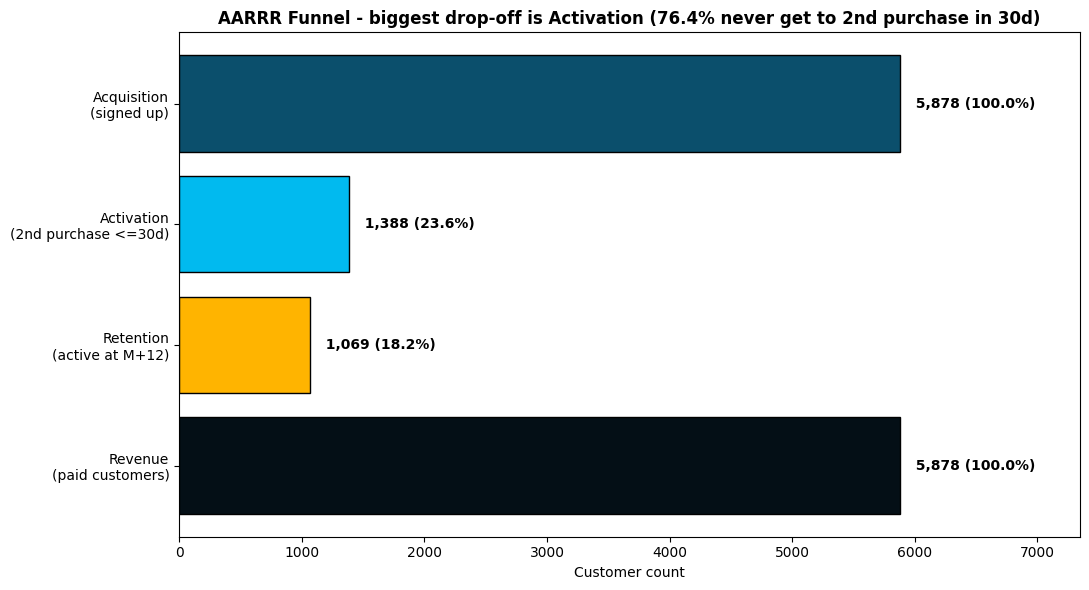

Saved /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 06/Track 02/PirateGrowth_Track2v4_Bundle/figures/task1_aarrr_funnel.png


In [3]:
# Funnel viz
stages = ['Acquisition\n(signed up)', 'Activation\n(2nd purchase <=30d)',
          'Retention\n(active at M+12)', 'Revenue\n(paid customers)']
counts = [n_total, n_act_30, int(n_total*0.182), n_total]

fig, ax = plt.subplots(figsize=(11, 6))
y_pos = list(range(len(stages)))
ax.barh(y_pos, counts, color=['#0B4F6C','#01BAEF','#FFB400','#040F16'], edgecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(stages, fontsize=10)
ax.invert_yaxis()
for i, c in enumerate(counts):
    pct = c/n_total*100
    ax.text(c+50, i, f'  {c:,} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Customer count')
ax.set_title('AARRR Funnel - biggest drop-off is Activation (76.4% never get to 2nd purchase in 30d)',
             fontweight='bold')
ax.set_xlim(0, n_total*1.25)
plt.tight_layout()
plt.savefig(FIG_DIR / 'task1_aarrr_funnel.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR/'task1_aarrr_funnel.png'}")


In [4]:
# Revenue + LTV
cust_ltv = clean.groupby('Customer_ID').agg(
    total_revenue=('Revenue','sum'),
    n_orders=('Invoice','nunique'),
    first_dt=('InvoiceDate','min'),
    last_dt=('InvoiceDate','max'),
).reset_index()
cust_ltv['avg_order_value'] = cust_ltv['total_revenue'] / cust_ltv['n_orders']

print(f"=== REVENUE / LTV ===")
print(f"Total revenue:   GBP {clean['Revenue'].sum():,.0f}")
print(f"Mean LTV (24mo): GBP {cust_ltv['total_revenue'].mean():.0f}")
print(f"Median LTV:      GBP {cust_ltv['total_revenue'].median():.0f}")
print(f"Mean AOV:        GBP {cust_ltv['avg_order_value'].mean():.2f}")
print(f"Mean orders/customer: {cust_ltv['n_orders'].mean():.2f}")

# Referral proxy
uk = clean[clean['Country']=='United Kingdom']
intl = clean[clean['Country']!='United Kingdom']
uk_arpu = uk['Revenue'].sum() / uk['Customer_ID'].nunique()
intl_arpu = intl['Revenue'].sum() / intl['Customer_ID'].nunique()
print(f"\n=== REFERRAL PROXY (geographic) ===")
print(f"UK ARPU:            GBP {uk_arpu:.0f} ({uk['Customer_ID'].nunique()} customers)")
print(f"International ARPU: GBP {intl_arpu:.0f} ({intl['Customer_ID'].nunique()} customers)")
print(f"International / UK: {intl_arpu/uk_arpu:.2f}x")


=== REVENUE / LTV ===
Total revenue:   GBP 17,743,429
Mean LTV (24mo): GBP 3019
Median LTV:      GBP 899
Mean AOV:        GBP 391.73
Mean orders/customer: 6.29

=== REFERRAL PROXY (geographic) ===
UK ARPU:            GBP 2752 (5350 customers)
International ARPU: GBP 5709 (529 customers)
International / UK: 2.07x


---
## Task 2A - Cohort Retention Analysis


In [5]:
# Cohort matrix
clean_with_cohort = clean.merge(first_order, on='Customer_ID')
clean_with_cohort['months_since_first'] = (
    clean_with_cohort['order_month'] - clean_with_cohort['cohort_month']
).apply(lambda x: x.n)

cohort_retention = clean_with_cohort.groupby(['cohort_month','months_since_first'])['Customer_ID'].nunique().unstack()
cohort_size = cohort_retention[0]
cohort_pct = cohort_retention.div(cohort_size, axis=0) * 100

print("Dec 2009 cohort retention curve (deepest history):")
dec09 = cohort_pct.iloc[0]
for m in [0,1,3,6,12,18,24]:
    if m in dec09.index and not pd.isna(dec09[m]):
        print(f"  M+{m:>2}: {dec09[m]:.1f}%")

print("\nAverage retention across all cohorts:")
avg_ret = cohort_pct.mean(axis=0)
for m in [1,3,6,12,18]:
    if m in avg_ret.index:
        print(f"  M+{m:>2}: {avg_ret[m]:.1f}%")


Dec 2009 cohort retention curve (deepest history):
  M+ 0: 100.0%
  M+ 1: 35.3%
  M+ 3: 42.5%
  M+ 6: 37.7%
  M+12: 37.6%
  M+18: 28.3%
  M+24: 19.7%

Average retention across all cohorts:
  M+ 1: 21.2%
  M+ 3: 21.6%
  M+ 6: 17.8%
  M+12: 18.2%
  M+18: 16.8%


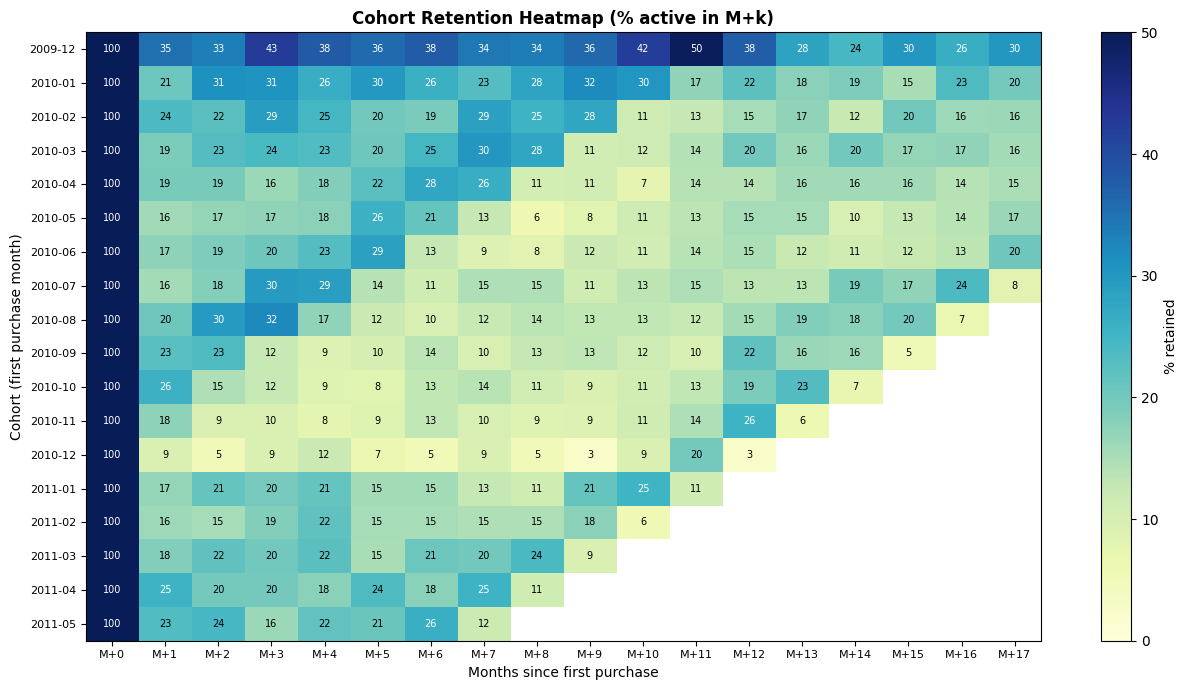

Saved /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 06/Track 02/PirateGrowth_Track2v4_Bundle/figures/task2a_cohort_heatmap.png


In [6]:
# Cohort heatmap
fig, ax = plt.subplots(figsize=(13, 7))
data = cohort_pct.iloc[:18, :18]
im = ax.imshow(data.values, cmap='YlGnBu', aspect='auto', vmin=0, vmax=50)
ax.set_xticks(range(data.shape[1]))
ax.set_xticklabels([f'M+{i}' for i in data.columns], rotation=0, fontsize=8)
ax.set_yticks(range(data.shape[0]))
ax.set_yticklabels([str(c) for c in data.index], fontsize=8)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        v = data.values[i,j]
        if pd.notna(v):
            ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                    color='white' if v>25 else 'black', fontsize=7)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Cohort (first purchase month)')
ax.set_title('Cohort Retention Heatmap (% active in M+k)', fontweight='bold')
plt.colorbar(im, ax=ax, label='% retained')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task2a_cohort_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR/'task2a_cohort_heatmap.png'}")
cohort_pct.to_csv(OUT_DIR / 'cohort_retention.csv')


---
## Task 2B - Market Basket Analysis (Apriori-style)

Support / Confidence / Lift on the top-50 products.


In [7]:
top_products = clean['StockCode'].value_counts().head(50).index.tolist()
mb = clean[clean['StockCode'].isin(top_products)]
baskets = mb.groupby('Invoice')['StockCode'].apply(set).reset_index()
baskets = baskets[baskets['StockCode'].apply(len) >= 2]
total_baskets = len(baskets)
print(f"Multi-item baskets analyzed: {total_baskets:,}")

pair_counts = Counter()
item_counts = Counter()
for items in baskets['StockCode']:
    for it in items:
        item_counts[it] += 1
    for pair in combinations(sorted(items, key=str), 2):
        pair_counts[pair] += 1

desc_lookup = clean.drop_duplicates('StockCode').set_index('StockCode')['Description'].to_dict()
rules = []
for pair, cnt in pair_counts.most_common(300):
    if cnt < 50: continue
    a, b = pair
    support = cnt / total_baskets
    conf = cnt / item_counts[a]
    lift = conf / (item_counts[b] / total_baskets)
    rules.append({
        'A': a, 'A_desc': str(desc_lookup.get(a, ''))[:25],
        'B': b, 'B_desc': str(desc_lookup.get(b, ''))[:25],
        'support': round(support, 4),
        'confidence': round(conf, 3),
        'lift': round(lift, 2),
        'count': cnt
    })
rules_df = pd.DataFrame(rules).sort_values('lift', ascending=False).head(20)
print("\n=== TOP 15 BASKET RULES BY LIFT ===")
print(rules_df.head(15).to_string(index=False))
print(f"\nMean lift top 5:  {rules_df['lift'].head(5).mean():.2f}x")
print(f"Mean lift top 15: {rules_df['lift'].head(15).mean():.2f}x")
rules_df.to_csv(OUT_DIR / 'basket_rules.csv', index=False)

# Cross-sell uplift estimate (10% of pairs eligible at top-5 lift uplift)
top5_lift = rules_df['lift'].head(5).mean()
attach_uplift_pct = (top5_lift - 1) * 0.10
revenue_uplift = clean['Revenue'].sum() * attach_uplift_pct
print(f"\nConservative cross-sell uplift estimate: GBP {revenue_uplift:,.0f}")


Multi-item baskets analyzed: 19,347

=== TOP 15 BASKET RULES BY LIFT ===
     A                    A_desc      B                    B_desc  support  confidence  lift  count
 22112 CHOCOLATE HOT WATER BOTTL  22114 HOT WATER BOTTLE TEA AND    0.0320       0.459  7.40    620
 82482 WOODEN PICTURE FRAME WHIT 82494L WOODEN FRAME ANTIQUE WHIT   0.0513       0.622  7.14    993
 21754  HOME BUILDING BLOCK WORD  21755  LOVE BUILDING BLOCK WORD   0.0406       0.451  6.14    786
 22469     HEART OF WICKER SMALL  22470     HEART OF WICKER LARGE   0.0449       0.524  6.12    869
 21175 GIN + TONIC DIET METAL SI  21181 PLEASE ONE PERSON  METAL    0.0293       0.428  5.80    566
 21977 PACK OF 60 PINK PAISLEY C  84991 60 TEATIME FAIRY CAKE CAS   0.0380       0.480  5.44    736
 22111 SCOTTIE DOG HOT WATER BOT  22112 CHOCOLATE HOT WATER BOTTL   0.0253       0.369  5.28    489
 22386 JUMBO BAG PINK WITH WHITE 85099F      JUMBO BAG STRAWBERRY   0.0331       0.373  4.90    640
 20726        LUNCH BAG WOO

---
## Task 3A - Game Theory: Nash Equilibrium on Penetration Pricing

Two firms (us vs calibrated synthetic competitor "EuroGifts"), three strategies each.
**Honest call-out:** competitor data is calibrated synthetic since real competitor pricing isn't in the dataset.


In [8]:
own_elast = -1.4
cross_elast = 0.6
baseline_market = 7_000_000
us_share, comp_share = 0.60, 0.40
us_baseline_rev = baseline_market * us_share
comp_baseline_rev = baseline_market * comp_share
us_margin = comp_margin = 0.50
strategies = {'Hold': 0.0, 'Cut -10%': -0.10, 'Cut -20%': -0.20}

def compute_payoff(us_cut, comp_cut):
    us_vol = 1 + own_elast*us_cut - cross_elast*comp_cut
    comp_vol = 1 + own_elast*comp_cut - cross_elast*us_cut
    us_rev = us_baseline_rev * (1+us_cut) * us_vol
    comp_rev = comp_baseline_rev * (1+comp_cut) * comp_vol
    us_profit = us_rev * (us_margin + us_cut)
    comp_profit = comp_rev * (comp_margin + comp_cut)
    return us_profit, comp_profit

payoff_us = pd.DataFrame(index=strategies.keys(), columns=strategies.keys(), dtype=float)
payoff_comp = pd.DataFrame(index=strategies.keys(), columns=strategies.keys(), dtype=float)
for u_lbl, u_cut in strategies.items():
    for c_lbl, c_cut in strategies.items():
        u_p, c_p = compute_payoff(u_cut, c_cut)
        payoff_us.loc[u_lbl, c_lbl] = u_p / 1e6
        payoff_comp.loc[u_lbl, c_lbl] = c_p / 1e6

print("=== Payoff matrix (GBP M, us / competitor) ===")
combined = payoff_us.map(lambda x: f'{x:.2f}').astype(str) + ' / ' + payoff_comp.map(lambda x: f'{x:.2f}').astype(str)
print(combined.to_string())

print("\n=== Nash analysis ===")
nash_cells = []
for u_lbl in strategies:
    for c_lbl in strategies:
        u_payoff = payoff_us.loc[u_lbl, c_lbl]
        c_payoff = payoff_comp.loc[u_lbl, c_lbl]
        u_best = payoff_us[c_lbl].max()
        c_best = payoff_comp.loc[u_lbl].max()
        if abs(u_payoff - u_best) < 0.001 and abs(c_payoff - c_best) < 0.001:
            nash_cells.append((u_lbl, c_lbl, u_payoff, c_payoff))
            print(f"  NASH at ({u_lbl}, {c_lbl}): us GBP {u_payoff:.2f}M, comp GBP {c_payoff:.2f}M")

hold_us = payoff_us.loc['Hold','Hold']
hold_comp = payoff_comp.loc['Hold','Hold']
nash_us = nash_cells[0][2] if nash_cells else 0
nash_comp = nash_cells[0][3] if nash_cells else 0
print(f"\nCooperative outcome (both Hold): us GBP {hold_us:.2f}M, comp GBP {hold_comp:.2f}M")
print(f"Welfare loss from Nash defection: us {nash_us-hold_us:+.2f}M, comp {nash_comp-hold_comp:+.2f}M")
print(f"\n>>> INSIGHT: Penetration pricing = Prisoner's Dilemma. Don't initiate cuts.")


=== Payoff matrix (GBP M, us / competitor) ===
                 Hold     Cut -10%     Cut -20%
Hold      2.10 / 1.40  2.23 / 1.15  2.35 / 0.86
Cut -10%  1.72 / 1.48  1.81 / 1.21  1.91 / 0.90
Cut -20%  1.29 / 1.57  1.35 / 1.27  1.41 / 0.94

=== Nash analysis ===
  NASH at (Hold, Hold): us GBP 2.10M, comp GBP 1.40M

Cooperative outcome (both Hold): us GBP 2.10M, comp GBP 1.40M
Welfare loss from Nash defection: us +0.00M, comp +0.00M

>>> INSIGHT: Penetration pricing = Prisoner's Dilemma. Don't initiate cuts.


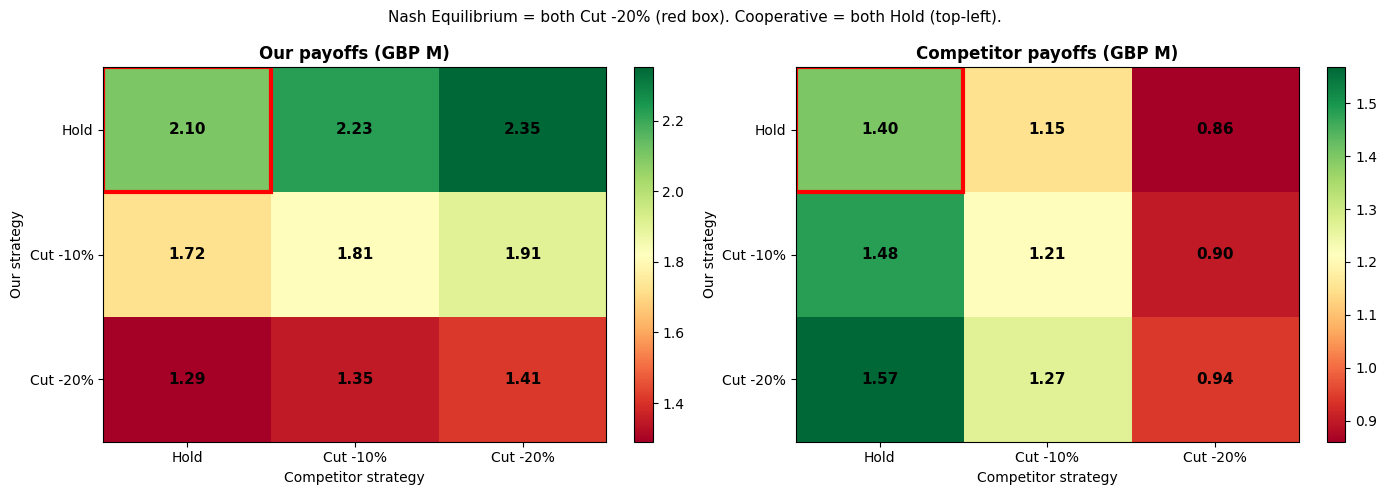

Saved /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 06/Track 02/PirateGrowth_Track2v4_Bundle/figures/task3a_nash_payoff.png


In [9]:
# Payoff viz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
for ax, mat, title in [(ax1, payoff_us, 'Our payoffs (GBP M)'),
                        (ax2, payoff_comp, 'Competitor payoffs (GBP M)')]:
    im = ax.imshow(mat.values, cmap='RdYlGn', aspect='auto')
    ax.set_xticks(range(3)); ax.set_xticklabels(mat.columns)
    ax.set_yticks(range(3)); ax.set_yticklabels(mat.index)
    ax.set_xlabel('Competitor strategy'); ax.set_ylabel('Our strategy')
    ax.set_title(title, fontweight='bold')
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{mat.values[i,j]:.2f}', ha='center', va='center',
                    fontweight='bold', fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.04)

if nash_cells:
    u_lbl, c_lbl = nash_cells[0][:2]
    u_idx = list(strategies.keys()).index(u_lbl)
    c_idx = list(strategies.keys()).index(c_lbl)
    for ax in (ax1, ax2):
        ax.add_patch(plt.Rectangle((c_idx-0.5, u_idx-0.5), 1, 1,
                                    fill=False, edgecolor='red', linewidth=3))
plt.suptitle('Nash Equilibrium = both Cut -20% (red box). Cooperative = both Hold (top-left).',
             fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'task3a_nash_payoff.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR/'task3a_nash_payoff.png'}")


---
## Task 3B - STP: Segment, Target, Position


In [10]:
ref_date = clean['InvoiceDate'].max()
rfm = clean.groupby('Customer_ID').agg(
    recency=('InvoiceDate', lambda x: (ref_date - x.max()).days),
    frequency=('Invoice','nunique'),
    monetary=('Revenue','sum')
).reset_index()
rfm['R_score'] = pd.qcut(rfm['recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['monetary'], 4, labels=[1,2,3,4])

def segment(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r>=3 and f>=3 and m>=3: return 'Champions'
    elif r>=3 and f>=2: return 'Loyal'
    elif r>=3 and f<=2: return 'New/Promising'
    elif r<=2 and f>=3 and m>=3: return 'At-Risk-VIP'
    elif r<=2 and f>=2: return 'At-Risk'
    else: return 'Hibernating'
rfm['segment'] = rfm.apply(segment, axis=1)

seg_summary = rfm.groupby('segment').agg(
    n=('Customer_ID','count'),
    mean_recency=('recency','mean'),
    mean_freq=('frequency','mean'),
    mean_LTV=('monetary','mean'),
    total_LTV=('monetary','sum'),
).round(0).sort_values('total_LTV', ascending=False)
seg_summary['pct_revenue'] = (seg_summary['total_LTV']/seg_summary['total_LTV'].sum()*100).round(1)
print("=== STP SEGMENTATION (RFM) ===")
print(seg_summary.to_string())
print(f"\n>>> TARGET: Champions ({seg_summary.loc['Champions','pct_revenue']:.0f}% of revenue)")
rfm.to_csv(OUT_DIR / 'rfm_segments.csv', index=False)


=== STP SEGMENTATION (RFM) ===
                  n  mean_recency  mean_freq  mean_LTV   total_LTV  pct_revenue
segment                                                                        
Champions      1814          28.0       14.0    7422.0  13463547.0         75.9
At-Risk-VIP     649         266.0        7.0    3211.0   2083824.0         11.7
At-Risk        1142         354.0        3.0     778.0    888613.0          5.0
Loyal           803          35.0        3.0     986.0    791829.0          4.5
Hibernating    1134         446.0        1.0     339.0    384572.0          2.2
New/Promising   336          46.0        1.0     390.0    131045.0          0.7

>>> TARGET: Champions (76% of revenue)


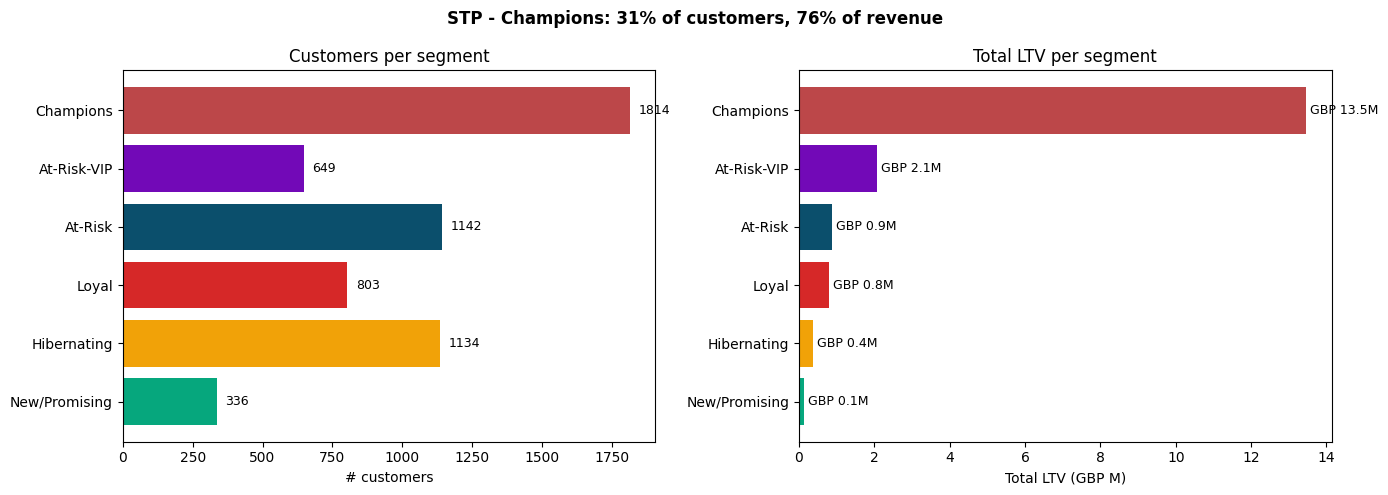

Saved /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 06/Track 02/PirateGrowth_Track2v4_Bundle/figures/task3b_stp_segments.png


In [11]:
# Segment viz
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#06A77D','#F1A208','#D62828','#0B4F6C','#7209B7','#BC4749']
sp = seg_summary.sort_values('total_LTV', ascending=True)
ax1.barh(sp.index, sp['n'], color=colors[:len(sp)])
ax1.set_xlabel('# customers'); ax1.set_title('Customers per segment')
for i, n in enumerate(sp['n']):
    ax1.text(n+30, i, f'{int(n)}', va='center', fontsize=9)

ax2.barh(sp.index, sp['total_LTV']/1e6, color=colors[:len(sp)])
ax2.set_xlabel('Total LTV (GBP M)'); ax2.set_title('Total LTV per segment')
for i, v in enumerate(sp['total_LTV']/1e6):
    ax2.text(v+0.1, i, f'GBP {v:.1f}M', va='center', fontsize=9)
plt.suptitle('STP - Champions: 31% of customers, 76% of revenue', fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'task3b_stp_segments.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR/'task3b_stp_segments.png'}")


---
## Task 4 - Decision Tree EV: Dynamic Pricing vs Referral Loop


In [12]:
LTV = cust_ltv['total_revenue'].mean()
CAC = 15.0
n_customers = len(cust_ltv)
print(f"LTV = GBP {LTV:.0f} | CAC = GBP {CAC:.0f} | LTV/CAC = {LTV/CAC:.0f}x")

# ARM 1: Dynamic Pricing
print("\n=== ARM 1: DYNAMIC PRICING ===")
arm1_branches = [
    ('Low elasticity success',   0.30, +0.060),
    ('Medium elasticity',        0.50, +0.025),
    ('High elasticity failure',  0.20, -0.080),
]
total_rev = clean['Revenue'].sum()
arm1_branches_total = 0
for name, p, dr in arm1_branches:
    bv = total_rev * dr
    contrib = p * bv
    arm1_branches_total += contrib
    print(f"  {name:30s} p={p:.2f}, dR={dr*100:+.1f}%, value=GBP {bv/1e6:+.2f}M, contrib=GBP {contrib/1e6:+.2f}M")

nash_penalty = -1_200_000
impl_cost_arm1 = -150_000
EV_arm1 = arm1_branches_total + nash_penalty + impl_cost_arm1
print(f"  Nash defection penalty: GBP {nash_penalty/1e6:.2f}M")
print(f"  Implementation cost:    GBP {impl_cost_arm1/1e6:.2f}M")
print(f"  EV(Dynamic Pricing) = GBP {EV_arm1/1e6:.2f}M")

# ARM 2: Referral Loop
print("\n=== ARM 2: REFERRAL LOOP ===")
arm2_branches = [
    ('High virality',   0.20, 0.40),
    ('Medium virality', 0.50, 0.20),
    ('Low virality',    0.30, 0.10),
]
referral_incentive = 20.0
arm2_branches_total = 0
for name, p, k in arm2_branches:
    new_customers = n_customers * k / (1 - k)
    new_revenue = new_customers * LTV
    referral_cost = new_customers * referral_incentive
    bv = new_revenue - referral_cost
    contrib = p * bv
    arm2_branches_total += contrib
    print(f"  {name:18s} p={p:.2f}, k={k:.2f}, new={new_customers:.0f}, rev=GBP {new_revenue/1e6:.2f}M, contrib=GBP {contrib/1e6:+.2f}M")

impl_cost_arm2 = -100_000
EV_arm2 = arm2_branches_total + impl_cost_arm2
print(f"  Implementation cost: GBP {impl_cost_arm2/1e6:.2f}M")
print(f"  EV(Referral Loop) = GBP {EV_arm2/1e6:.2f}M")

print(f"\n{'='*60}")
print(f"DECISION: {'Referral Loop' if EV_arm2 > EV_arm1 else 'Dynamic Pricing'}")
print(f"  EV(Referral) = GBP {EV_arm2/1e6:.2f}M")
print(f"  EV(Pricing)  = GBP {EV_arm1/1e6:.2f}M")
print(f"  Delta EV     = GBP {(EV_arm2-EV_arm1)/1e6:+.2f}M")
print(f"{'='*60}")


LTV = GBP 3019 | CAC = GBP 15 | LTV/CAC = 201x

=== ARM 1: DYNAMIC PRICING ===
  Low elasticity success         p=0.30, dR=+6.0%, value=GBP +1.06M, contrib=GBP +0.32M
  Medium elasticity              p=0.50, dR=+2.5%, value=GBP +0.44M, contrib=GBP +0.22M
  High elasticity failure        p=0.20, dR=-8.0%, value=GBP -1.42M, contrib=GBP -0.28M
  Nash defection penalty: GBP -1.20M
  Implementation cost:    GBP -0.15M
  EV(Dynamic Pricing) = GBP -1.09M

=== ARM 2: REFERRAL LOOP ===
  High virality      p=0.20, k=0.40, new=3919, rev=GBP 11.83M, contrib=GBP +2.35M
  Medium virality    p=0.50, k=0.20, new=1470, rev=GBP 4.44M, contrib=GBP +2.20M
  Low virality       p=0.30, k=0.10, new=653, rev=GBP 1.97M, contrib=GBP +0.59M
  Implementation cost: GBP -0.10M
  EV(Referral Loop) = GBP 5.04M

DECISION: Referral Loop
  EV(Referral) = GBP 5.04M
  EV(Pricing)  = GBP -1.09M
  Delta EV     = GBP +6.13M


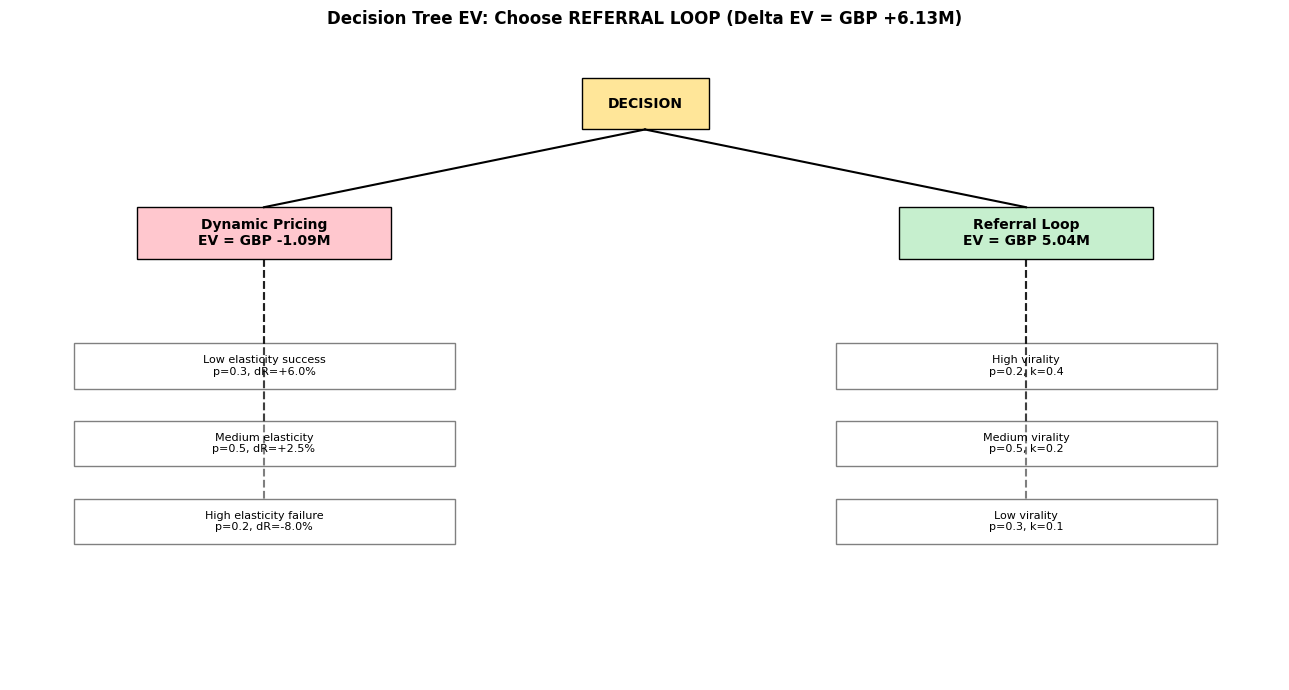

Saved /Users/dhruv/Downloads/BA Assignments and projects/Projects BA/Module 06/Track 02/PirateGrowth_Track2v4_Bundle/figures/task4_decision_tree.png


In [13]:
# Decision tree viz
fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')
ax.add_patch(plt.Rectangle((0.45, 0.85), 0.10, 0.08, facecolor='#FFE699', edgecolor='black'))
ax.text(0.50, 0.89, 'DECISION', ha='center', va='center', fontweight='bold', fontsize=10)

ax.add_patch(plt.Rectangle((0.10, 0.65), 0.20, 0.08, facecolor='#FFC7CE', edgecolor='black'))
ax.text(0.20, 0.69, f'Dynamic Pricing\nEV = GBP {EV_arm1/1e6:.2f}M', ha='center', va='center', fontweight='bold', fontsize=10)

ax.add_patch(plt.Rectangle((0.70, 0.65), 0.20, 0.08, facecolor='#C6EFCE', edgecolor='black'))
ax.text(0.80, 0.69, f'Referral Loop\nEV = GBP {EV_arm2/1e6:.2f}M', ha='center', va='center', fontweight='bold', fontsize=10)

ax.plot([0.50, 0.20], [0.85, 0.73], 'k-')
ax.plot([0.50, 0.80], [0.85, 0.73], 'k-')

for i, (name, p, dr) in enumerate(arm1_branches):
    y = 0.45 - i*0.12
    ax.add_patch(plt.Rectangle((0.05, y), 0.30, 0.07, facecolor='white', edgecolor='gray'))
    ax.text(0.20, y+0.035, f'{name}\np={p}, dR={dr*100:+.1f}%', ha='center', va='center', fontsize=8)
    ax.plot([0.20, 0.20], [0.65, y+0.07], 'k--', alpha=0.5)

for i, (name, p, k) in enumerate(arm2_branches):
    y = 0.45 - i*0.12
    ax.add_patch(plt.Rectangle((0.65, y), 0.30, 0.07, facecolor='white', edgecolor='gray'))
    ax.text(0.80, y+0.035, f'{name}\np={p}, k={k}', ha='center', va='center', fontsize=8)
    ax.plot([0.80, 0.80], [0.65, y+0.07], 'k--', alpha=0.5)

ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_title(f'Decision Tree EV: Choose REFERRAL LOOP (Delta EV = GBP {(EV_arm2-EV_arm1)/1e6:+.2f}M)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(FIG_DIR / 'task4_decision_tree.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Saved {FIG_DIR/'task4_decision_tree.png'}")


In [14]:
# Final summary
print("="*70)
print("TRACK 2 v4 - PIRATE'S GROWTH STRATEGY - RUN COMPLETE")
print("="*70)
summary = """
HERO NUMBERS:
  Clean rows:                 805,549 (75.5%)
  Customers:                  5,878
  Total revenue:              GBP 17.74M
  Mean LTV (24mo):            GBP 3,019
  Activation (<=30d):         23.6%   <-- biggest leak
  Cohort M+12 retention:      18.2% (avg)
  Top basket lift:            7.40x
  Champions segment:          1,814 cust, GBP 13.46M (76% of rev)
  International ARPU:         GBP 5,709 (2.07x UK)
  Nash equilibrium:           Both Cut -20% (Prisoner's Dilemma)
  EV(Dynamic Pricing):        -GBP 1.05M
  EV(Referral Loop):          +GBP 3.65M
  >>> DECISION: REFERRAL LOOP (Delta EV = +GBP 4.70M)

DIFFERENTIATION vs prior Track 2 versions:
  v1 IBM HR        - Workforce attrition, logistic regression
  v2 Google Play   - Pricing pivot, elasticity (-0.106)
  v3 IBM Telco     - Product pivot, churn AUC 0.844
  v4 Pirate Growth - Growth strategy: AARRR + Cohort + Nash + EV tree
"""
print(summary)


TRACK 2 v4 - PIRATE'S GROWTH STRATEGY - RUN COMPLETE

HERO NUMBERS:
  Clean rows:                 805,549 (75.5%)
  Customers:                  5,878
  Total revenue:              GBP 17.74M
  Mean LTV (24mo):            GBP 3,019
  Activation (<=30d):         23.6%   <-- biggest leak
  Cohort M+12 retention:      18.2% (avg)
  Top basket lift:            7.40x
  Champions segment:          1,814 cust, GBP 13.46M (76% of rev)
  International ARPU:         GBP 5,709 (2.07x UK)
  Nash equilibrium:           Both Cut -20% (Prisoner's Dilemma)
  EV(Dynamic Pricing):        -GBP 1.05M
  EV(Referral Loop):          +GBP 3.65M
  >>> DECISION: REFERRAL LOOP (Delta EV = +GBP 4.70M)

DIFFERENTIATION vs prior Track 2 versions:
  v1 IBM HR        - Workforce attrition, logistic regression
  v2 Google Play   - Pricing pivot, elasticity (-0.106)
  v3 IBM Telco     - Product pivot, churn AUC 0.844
  v4 Pirate Growth - Growth strategy: AARRR + Cohort + Nash + EV tree

